In [1]:
import pandas  as pd
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df=pd.read_csv('Mall_Customers.csv')
print('\n first 3 rows')
print(df.head())


 first 3 rows
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
df.shape

(200, 5)

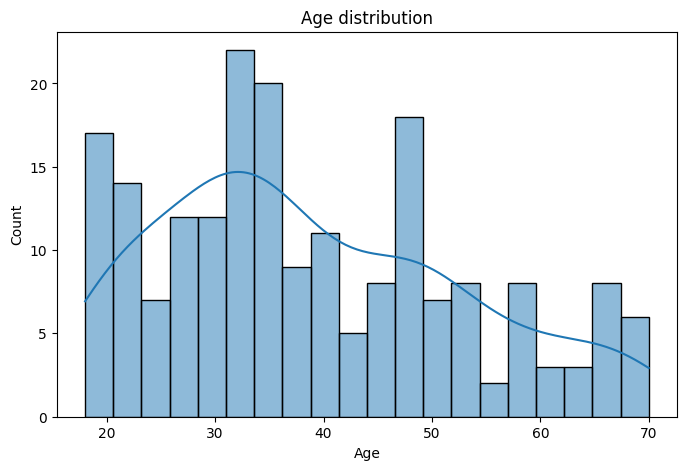

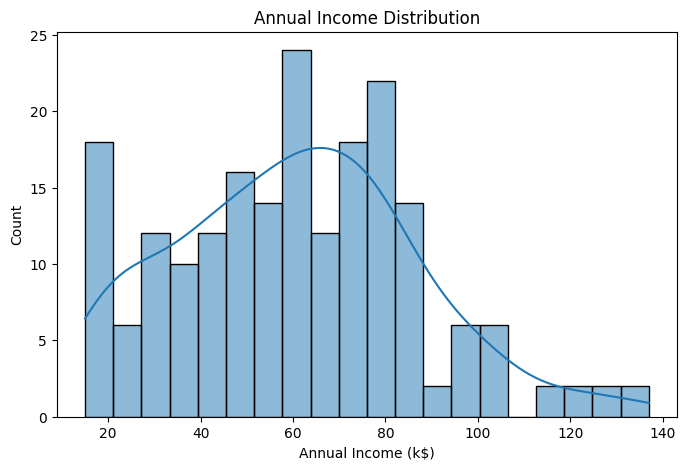

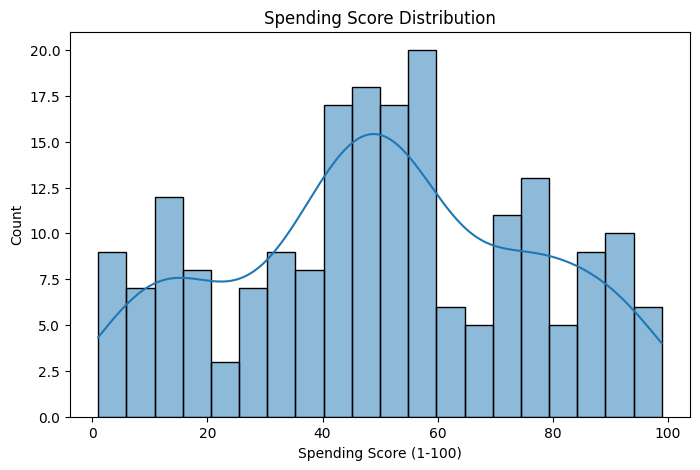

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20 , kde=True)
plt.title('Age distribution')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20 , kde=True)
plt.title('Annual Income Distribution')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20 , kde=True)
plt.title('Spending Score Distribution')
plt.show()

In [5]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]
print('\n Selected features')
print(X.head())


 Selected features
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('\n sacled Data shape')
print(X_scaled.shape)


 sacled Data shape
(200, 2)


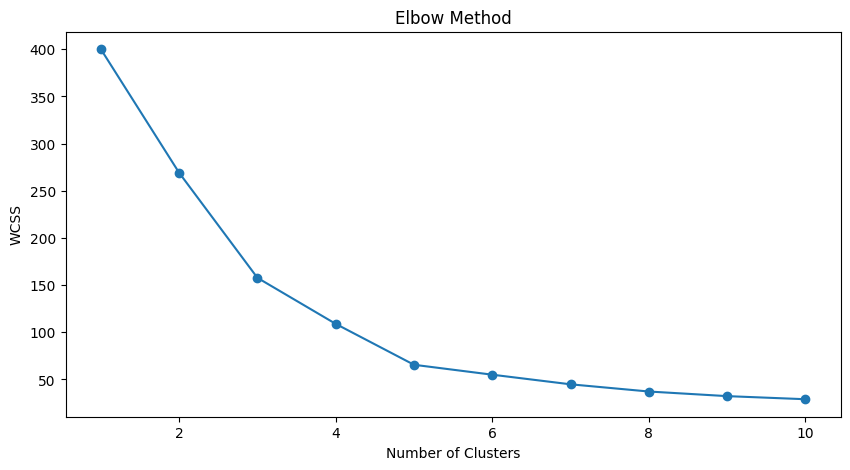

In [7]:
wcss=[]

for a in range(1,11):
    kmeans = KMeans(n_clusters=a, random_state=32, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)    

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [8]:
print('\n Silhouette scores')
for a in range(2,11):
    model = KMeans(n_clusters=a, random_state=32, n_init=10)
    
labels= model.fit_predict(X_scaled)   
score= silhouette_score(
    X_scaled, labels
) 
print(f'k={a}==> Score={score:.4f} ')


 Silhouette scores
k=10==> Score=0.4508 
